## This notebook demonstrates how to create cutouts from DR2 Mosaics on the STRW cluster using the `strw_lofar_data_utils` package. It covers:
- Loading mosaic data and generating cutouts from RA/Dec coordinates
- Working with source catalogues (discovered giants and master component catalogue)
- Using the CutoutCatalogue class to constrain catalogues to sources within cutout regions
- Converting catalogue sources to AstroObject instances with pixel position utilities
- Visualizing cutouts with catalogue source overlays

# Import necessary libraries and modules:

In [1]:
from astropy.table import Table
import pandas as pd
import numpy as np
import os

from src.pipelines import generate_cutouts
from src.core.vizualization import Vizualizer

# Load a catalogue from which we will extract the RA and Dec for cutout generation:

In [2]:
GIANTS_CATALOG = os.getcwd() + "/data/discovered_giants_catalogue.csv"
GIANTS_CATALOG

'/home/penchev/strw_lofar_data_utils/data/discovered_giants_catalogue.csv'

In [3]:
giants_df = pd.read_csv(GIANTS_CATALOG)
giants_df.head()

,recno,Name,RAJ2000,DEJ2000,LengthMpc,e_LengthMpc,LengthAng,z,e_z,Ref,FistDisc
0,10511,NaN,40.275764,8.737979,0.871,0.008,32.70,0.02121,0.00017,Oei et al. 2023,Oei et al. 2023
1,10358,NaN,38.802856,10.196330,1.014,0.607,15.60,0.05384,0.00000,Oei et al. 2023,Oei et al. 2023
2,10283,NaN,48.697044,15.149883,1.067,0.505,12.70,0.07104,0.00000,Oei et al. 2023,Oei et al. 2023
3,10938,NaN,42.945000,15.836940,0.918,0.000,2.46,0.48900,0.00000,Mahato et al. 2021,Mahato et al. 2021
4,10055,NaN,43.804028,17.514114,1.295,0.441,11.60,0.09725,0.00000,Oei et al. 2023,Oei et al. 2023


# Extract RA and Dec from the catalogue to define cutout regions:

In [4]:
# Get RA and DEC for the first 100 giants
ra_dec_list = list(
    zip(giants_df["RAJ2000"].values, giants_df["DEJ2000"].values)
)
ra_dec_list[:10]

[(40.275764, 8.737979),
 (38.802856, 10.19633),
 (48.697044, 15.149883),
 (42.945, 15.83694),
 (43.804028, 17.514114),
 (60.128278, 13.156841),
 (59.031086, 13.819252),
 (48.748005, 16.180998),
 (50.35795833333, 18.10273333333),
 (31.9861233, 16.96429532073)]

# Generate cutouts using the defined RA and Dec coordinates:

In [5]:
cutouts = generate_cutouts(
    ra_dec_list=ra_dec_list[:1000],
    size_pixels = 300,
    save=False,
)

Generating cutouts: 100%|██████████| 1000/1000 [00:13<00:00, 75.25it/s]


In [9]:
print(f"Generated {len(cutouts)} cutouts.")

Generated 859 cutouts.


# Load the Master Catalogue containg all the sources and their associated components.

In [10]:
# Read in the catalogues using astropy.table.Table to handle endianness
comp_cat = Table.read(
    "/net/vdesk/data2/penchev/project_data/data/combined_cat/combined-components-v0.8.fits" # Master catalogue
).to_pandas()

In [11]:
print(comp_cat.columns)
comp_cat.head()

Index(['Component_Name', 'RA', 'DEC', 'E_RA', 'E_DEC', 'Total_flux',
       'E_Total_flux', 'Peak_flux', 'E_Peak_flux', 'S_Code', 'Mosaic_ID',
       'Maj', 'Min', 'PA', 'E_Maj', 'E_Min', 'E_PA', 'DC_Maj', 'DC_Min',
       'DC_PA', 'FLAG_WORKFLOW', 'FC_flag3', 'ID_flag', 'Created',
       'Deblended_from', 'Parent_Source', 'Field'],
      dtype='object')


,Component_Name,RA,DEC,E_RA,E_DEC,Total_flux,E_Total_flux,Peak_flux,E_Peak_flux,S_Code,...,DC_Maj,DC_Min,DC_PA,FLAG_WORKFLOW,FC_flag3,ID_flag,Created,Deblended_from,Parent_Source,Field
0,b'ILTJ000000.03+213232.5',0.000111,21.542373,1.020193,1.161326,0.874979,0.321576,0.364927,0.098894,b'S',...,8.257653,5.959811,148.354890,7,13,1,b'Ingest components',NaN,b'ILTJ000000.03+213232.5',b'Fall'
1,b'ILTJ000000.03+195152.1',0.000140,19.864494,1.321657,0.916540,1.232928,0.432089,0.465850,0.122948,b'S',...,9.339157,6.139031,101.294149,8,14,1,b'Ingest components',NaN,b'ILTJ000000.03+195152.1',b'Fall'
2,b'ILTJ000000.04+295526.3',0.000182,29.923997,0.616315,0.572983,0.884912,0.274432,0.647176,0.127702,b'S',...,4.411160,2.773950,125.045066,7,13,1,b'Ingest components',NaN,b'ILTJ000000.04+295526.3',b'Fall'
3,b'ILTJ000000.06+335035.7',0.000237,33.843268,0.375925,0.255449,0.689347,0.152789,0.727052,0.090796,b'S',...,0.000000,0.000000,0.000000,8,14,1,b'Ingest components',NaN,b'ILTJ000000.06+335035.7',b'Fall'
4,b'ILTJ000000.08+320812.2',0.000352,32.136742,0.544358,0.710789,1.421767,0.319074,0.633838,0.103298,b'S',...,7.699121,5.697443,178.122904,7,13,1,b'Ingest components',NaN,b'ILTJ000000.08+320812.2',b'Fall'


Display 5 random cutouts

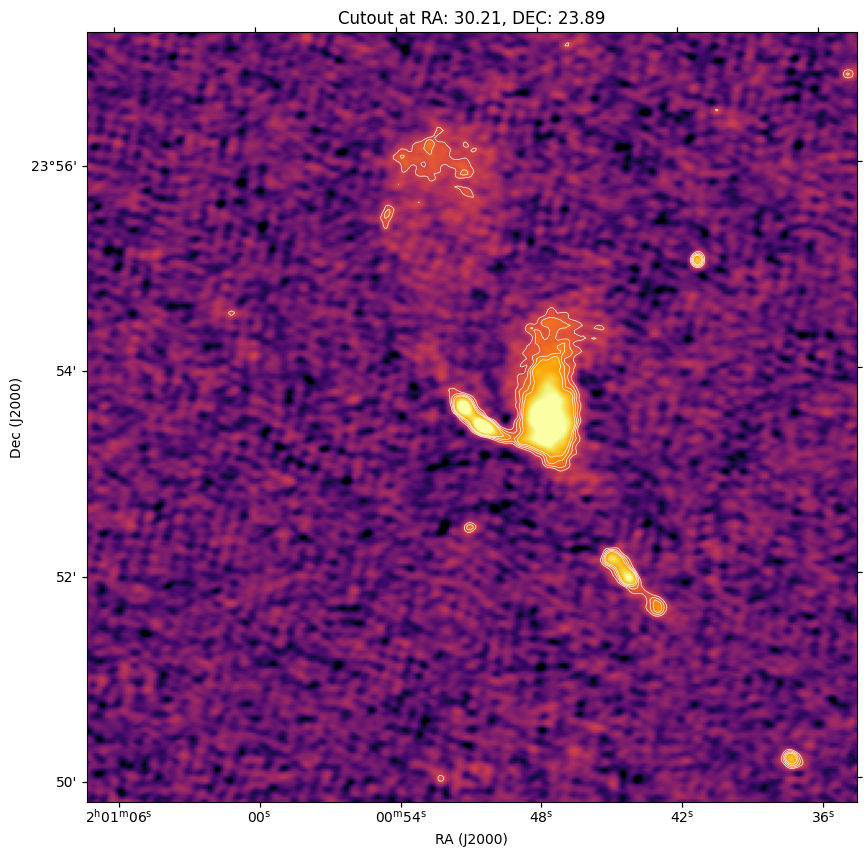

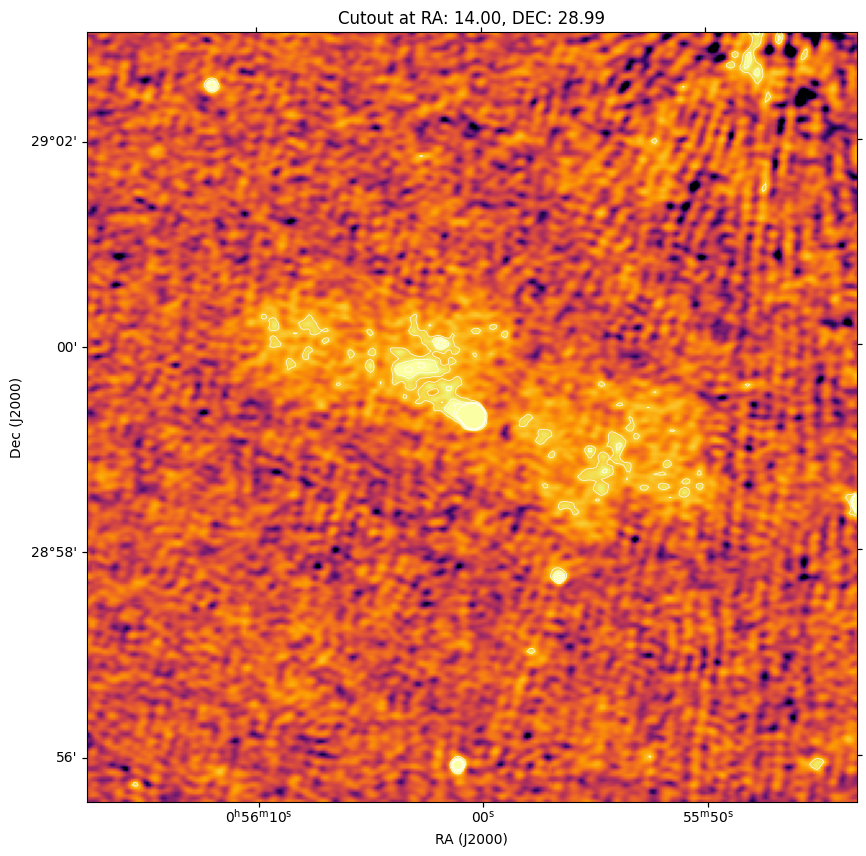

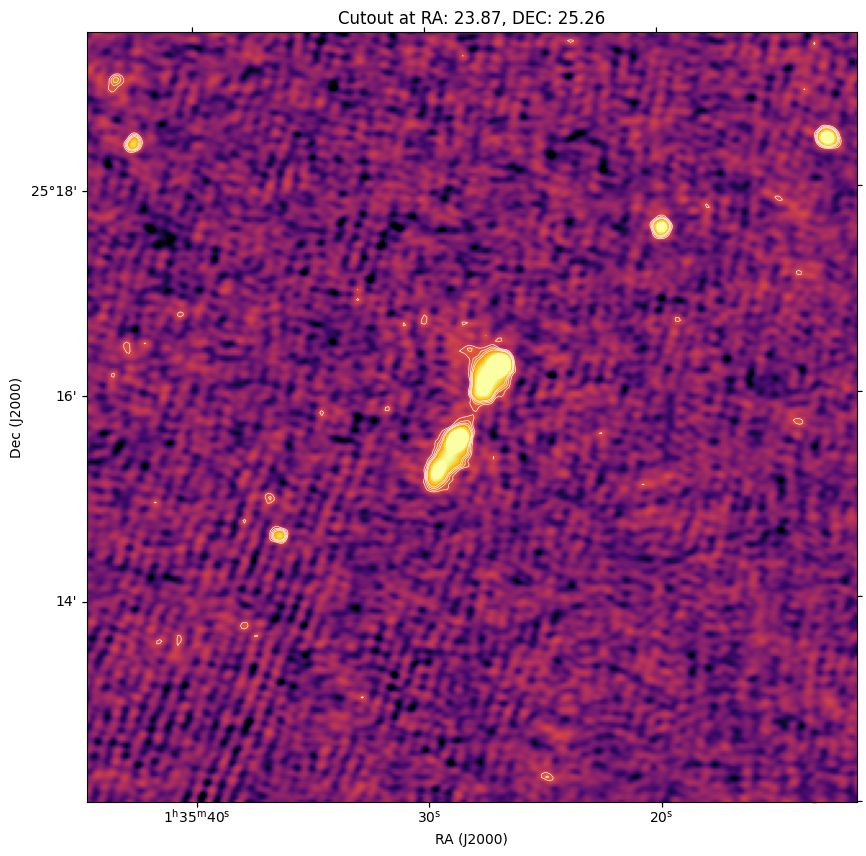

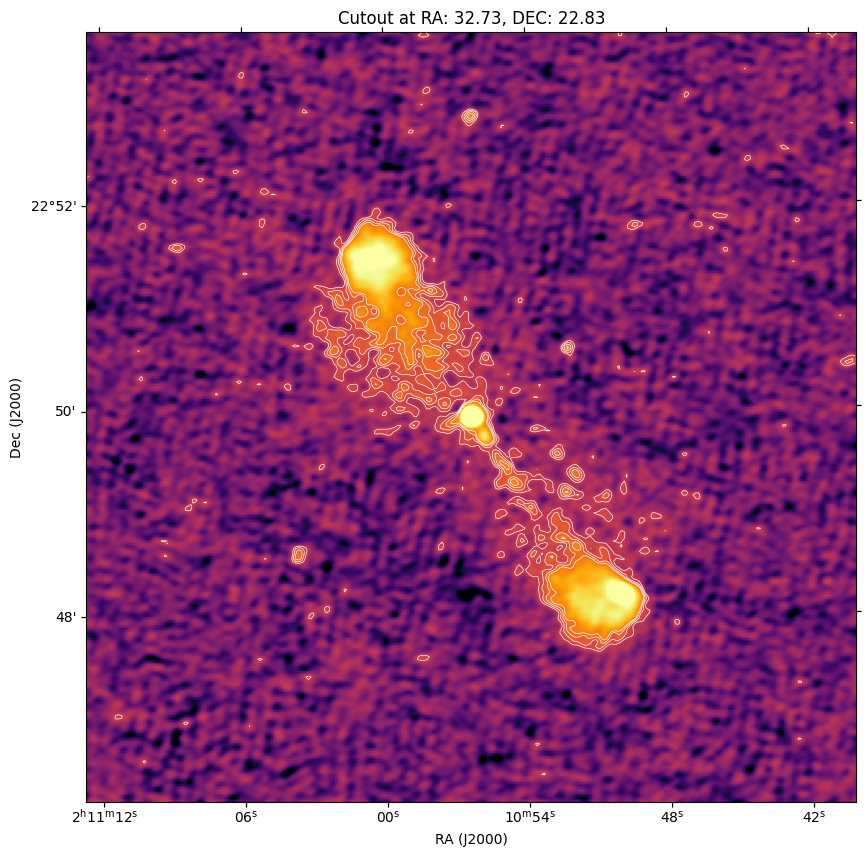

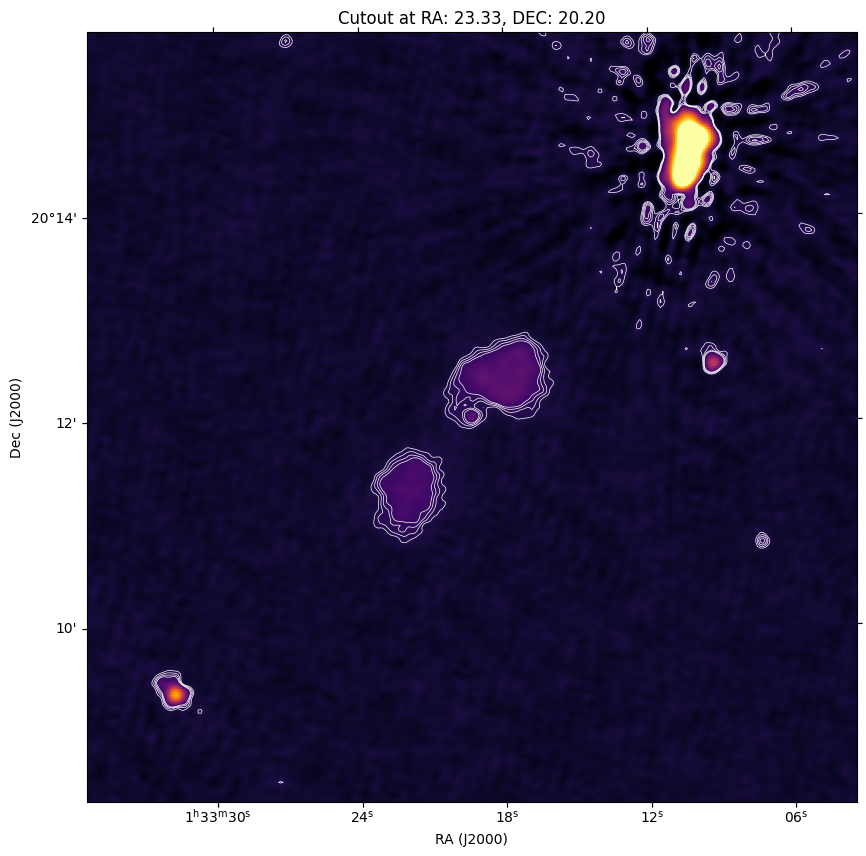

In [12]:
# Set the seed
np.random.seed(42)

# Get 5 random cutouts
random_cutouts = np.random.choice(cutouts, 5)
for cutout in random_cutouts:
    Vizualizer().vizualize_a_cutout(
        cutout=cutout,
        title=f"Cutout at RA: {cutout.ra:.2f}, DEC: {cutout.dec:.2f}",
        contour_levels=[4, 6, 8, 10]
    )

# We can get the pixel positions of the sources in the cutout using the CutoutCatalogue class:

We can constrain the component catalogue to include only sources that fall within the cutout area:

In [18]:
from src.core.cutout_maker.cutout_catalogue import CutoutCatalogue

selected_cutout = random_cutouts[0]
cutout_catalogue = CutoutCatalogue(
    cutout=selected_cutout,
    catalogue=comp_cat,
    ra_col='RA',
    dec_col='DEC',
    comp_col='Component_Name',
    source_col='Parent_Source'
)

constrained_cat = cutout_catalogue.get_constrained_catalogue()
print(f"Number of sources in the constrained catalogue: {len(constrained_cat)}")
constrained_cat.head()

Number of sources in the constrained catalogue: 12


,Component_Name,RA,DEC,E_RA,E_DEC,Total_flux,E_Total_flux,Peak_flux,E_Peak_flux,S_Code,...,DC_Maj,DC_Min,DC_PA,FLAG_WORKFLOW,FC_flag3,ID_flag,Created,Deblended_from,Parent_Source,Field
266685,b'ILTJ020034.74+235651.0',30.144742,23.947510,0.503940,0.337510,0.731551,0.187944,0.653605,0.099977,b'S',...,0.000000,0.000000,0.000000,17,41,1,b'Ingest components',NaN,b'ILTJ020034.74+235651.0',b'Fall'
266786,b'ILTJ020037.34+235011.0',30.155585,23.836399,0.251000,0.235491,2.937206,0.272408,1.457900,0.095583,b'S',...,7.224396,4.863607,50.461593,8,14,1,b'Ingest components',NaN,b'ILTJ020037.34+235011.0',b'Fall'
266917,b'ILTJ020041.21+235503.0',30.171698,23.917509,0.170575,0.217781,1.757028,0.208701,1.556344,0.110794,b'S',...,0.000000,0.000000,0.000000,7,13,1,b'Ingest components',NaN,b'ILTJ020041.21+235503.0',b'Fall'
267034,b'ILTJ020044.24+235158.5',30.184340,23.866255,0.441537,0.402969,14.136415,0.714564,2.161727,0.096794,b'M',...,30.832899,2.587428,41.947436,3,3,3,b'Ingest components',NaN,b'ILTJ020044.24+235158.5',b'Fall'
267173,b'ILTJ020047.39+235349.3',30.197468,23.897039,1.492941,0.543522,62.365357,3.205637,0.871756,0.113367,b'M',...,58.142600,21.729816,179.045453,3,3,3,b'Ingest components',NaN,b'ILTJ020049.13+235414.4',b'Fall'


We can get a dictionay containg all the sources in the cutout as AstroObject (see documentation) which contain utilities to get the pixel positions of the sources in the cutout:

In [28]:
ao_dict = cutout_catalogue.get_astro_objects_from_catalogue()

for source_name, astro_object in ao_dict.items():
    in_cutout = astro_object.check_if_in_cutout(
        cutout_wcs=selected_cutout.get_wcs(),
        cutout_shape=selected_cutout.get_data().shape
    )
    coords = astro_object.get_coords()
    pixel_positions = astro_object.get_pixel_positions()
    for idx in range(len(coords)):
        print(f"Source: {source_name} | In Cutout: {in_cutout[idx]} | RA: {coords[idx].ra} | DEC: {coords[idx].dec} | Pixel X: {pixel_positions[idx][0]:.2f} | Pixel Y: {pixel_positions[idx][1]:.2f}")

Source: b'ILTJ020034.74+235651.0' | In Cutout: True | RA: 30.144742324996283 deg | DEC: 23.94751027863 deg | Pixel X: 296.00 | Pixel Y: 282.00
Source: b'ILTJ020037.34+235011.0' | In Cutout: True | RA: 30.155584734943393 deg | DEC: 23.83639893219105 deg | Pixel X: 274.00 | Pixel Y: 16.00
Source: b'ILTJ020041.21+235503.0' | In Cutout: True | RA: 30.171697947883374 deg | DEC: 23.9175094386458 deg | Pixel X: 237.00 | Pixel Y: 210.00
Source: b'ILTJ020044.24+235158.5' | In Cutout: True | RA: 30.18433953027305 deg | DEC: 23.86625472778283 deg | Pixel X: 210.00 | Pixel Y: 87.00
Source: b'ILTJ020049.13+235414.4' | In Cutout: True | RA: 30.197467978914013 deg | DEC: 23.89703931788992 deg | Pixel X: 181.00 | Pixel Y: 161.00
Source: b'ILTJ020049.13+235414.4' | In Cutout: True | RA: 30.20214297081763 deg | DEC: 23.892086313336318 deg | Pixel X: 171.00 | Pixel Y: 149.00
Source: b'ILTJ020049.13+235414.4' | In Cutout: True | RA: 30.213531203837775 deg | DEC: 23.932650775462147 deg | Pixel X: 145.00 | 

Finally we can visualize the cutouts with an overlay of the catalogue sources:

In [15]:
from src.core.cutout_maker.cutout_catalogue import CutoutCatalogue

def show_cutout_with_catalogue_overlay(
    cutout,
    comp_cat: pd.DataFrame,
    title: str,
    contour_levels: list = [4, 6, 8, 10],
    cmap='gray',
    rms=0.1,
) -> None:
    """
    Show a cutout with an overlay of catalog objects.
    """
    # Create a cutout catalogue object to handle the overlay
    cutout_cat = CutoutCatalogue(
        catalogue=comp_cat,
        cutout=cutout,
        ra_col='RA',
        dec_col='DEC',
        comp_col='Component_Name',
        source_col='Parent_Source',
    )
    
    Vizualizer().vizualize_a_cutout_with_catalogue_objects(
        cutout=cutout,
        cutout_cat=cutout_cat,
        title=title,
        contour_levels=contour_levels,
        cmap=cmap,
        rms=rms,
    )

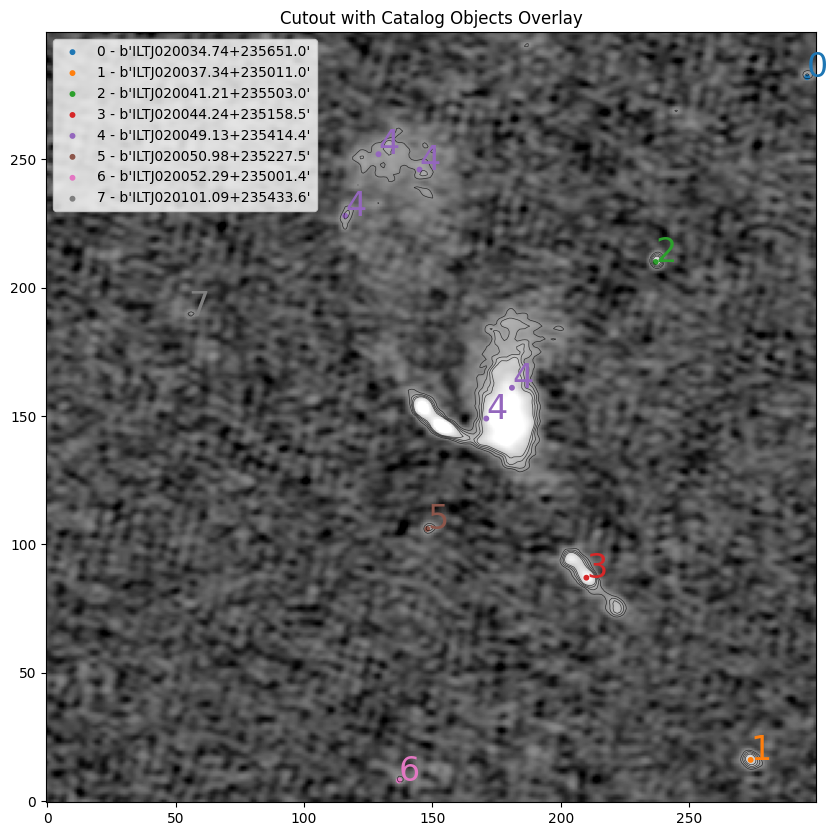

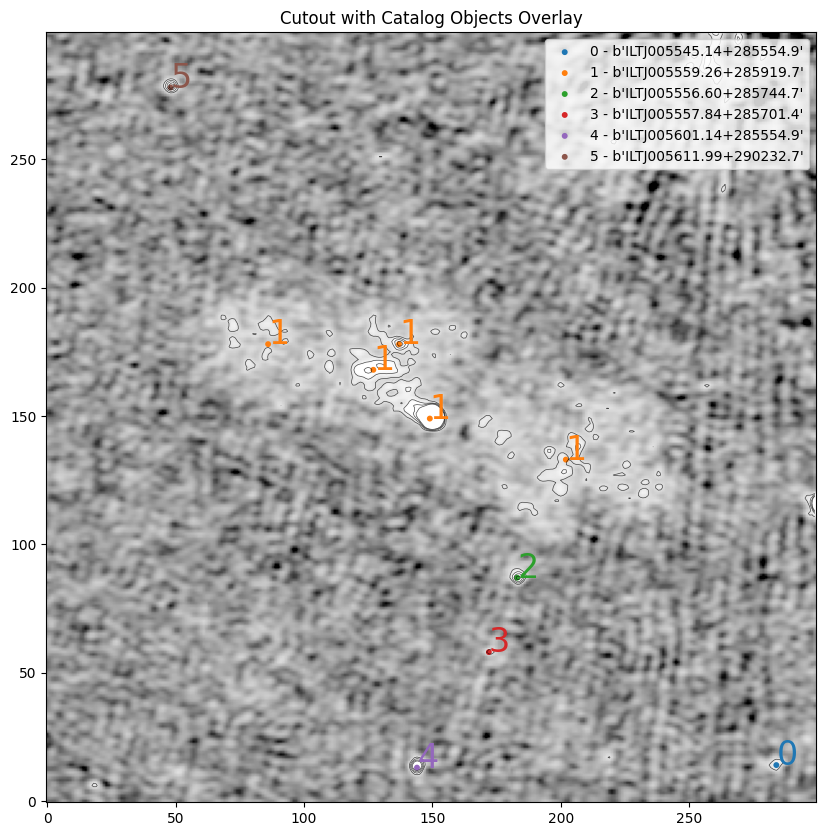

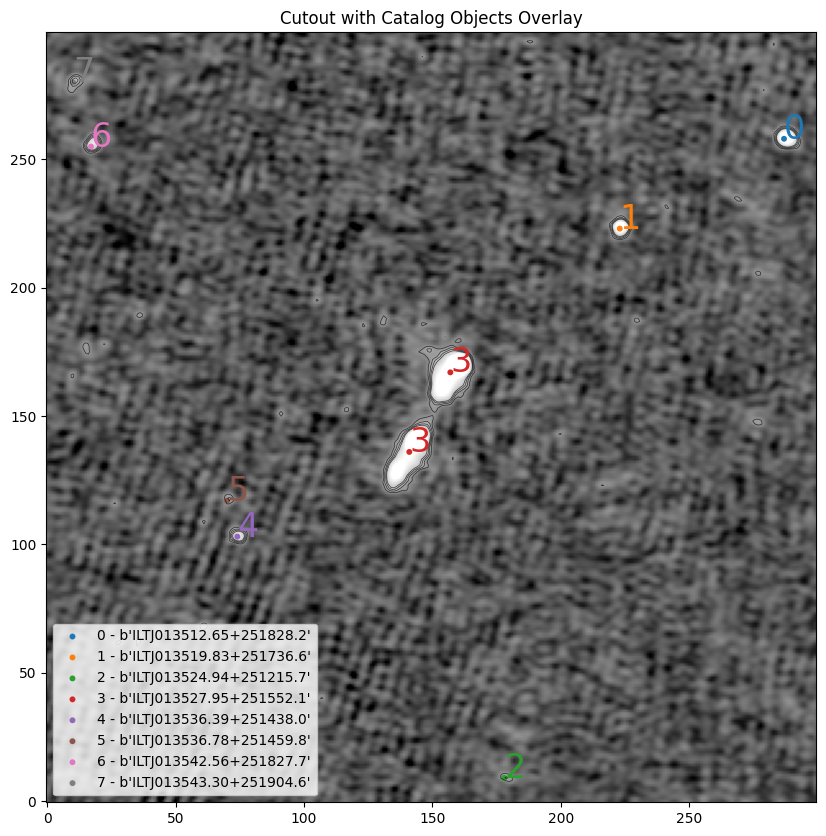

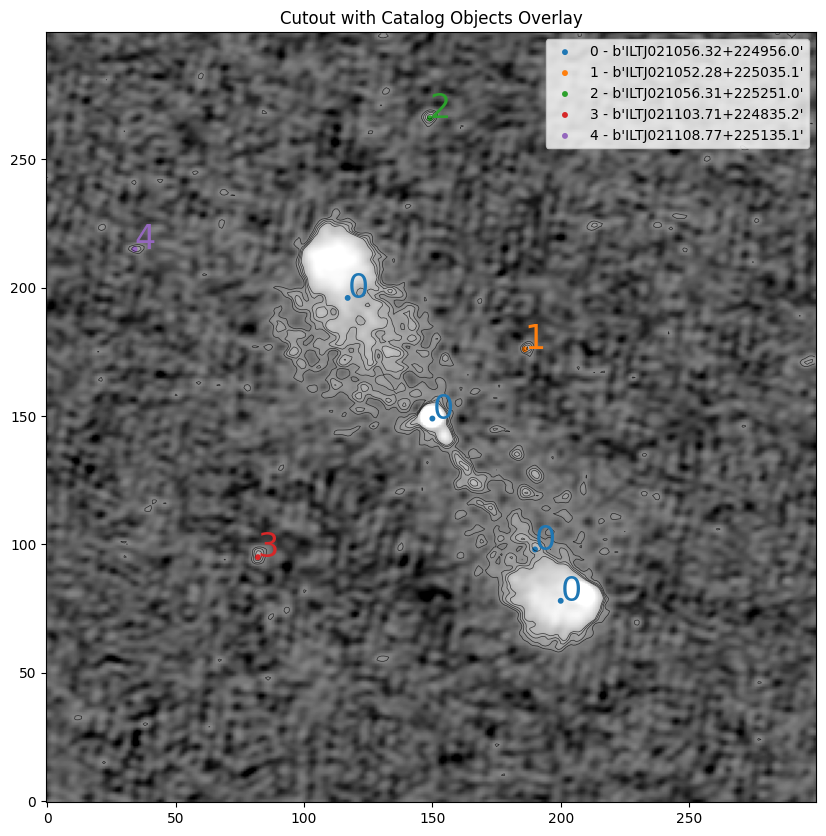

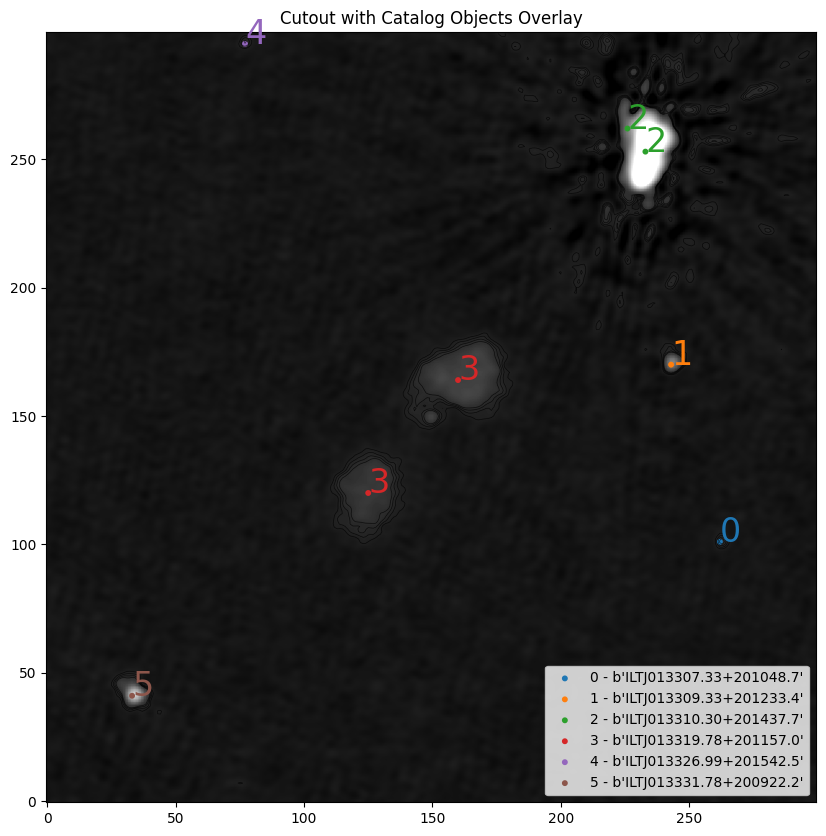

In [16]:
for cutout in random_cutouts:
    show_cutout_with_catalogue_overlay(
        cutout=cutout,
        comp_cat=comp_cat,
        title=f"Cutout at RA: {cutout.ra:.2f}, DEC: {cutout.dec:.2f} with Catalogue Overlay",
        contour_levels=[4, 6, 8, 10],
        cmap='gray',
        rms=0.1,
    )